# K-Nearest Neighbors para EMNIST Digits

En esta práctica se utiliza el algoritmo de KNN para la clasificación de los dígitos del dataset **EMNIST Digits**. Se clasifican las imágenes de los dígitos del 0 al 9.

El flujo del notebook es:
1. Cargar los datos
2. Utilizar los datos de entrenamiento para ver las métricas
3. Ver las métricas de los datos

## Instalación de librerías

Se utilizan librerías para cargar los datos y para las métricas.

In [4]:
from src.knn import predecir_masa_knn_vectorizado
from src.distancias import obtener_distancia
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

DISTANCIA = "manhattan"
N_TRAIN = -1 #-1 trae tooodo
N_TEST = 1730  #-1 trae tooodo
BATCH_SIZE = 16
TRAIN_CHUNK_SIZE = 2048

f_distancia = obtener_distancia(DISTANCIA)


## Carga de datos

Se cargan los datos desde `tensorflow_datasets`. Se dividen entre datos de entrenamiento y de testeto, para verificar la correctitud del modelo y para la obtención de métricas posteriormente.

In [5]:
(ds_train, ds_test), ds_info = tfds.load(
    "emnist/digits",
    split=["train", "test"],
    as_supervised=True,
    with_info=True,
)

train_size = ds_info.splits["train"].num_examples
test_size = ds_info.splits["test"].num_examples

x_train, y_train = next(iter(tfds.as_numpy(ds_train.batch(train_size))))
x_test, y_test = next(iter(tfds.as_numpy(ds_test.batch(test_size))))

if N_TRAIN != -1:
    x_train, y_train = x_train[:N_TRAIN], y_train[:N_TRAIN]
if N_TEST != -1:
    x_test, y_test = x_test[:N_TEST], y_test[:N_TEST]

num_classes = ds_info.features["label"].num_classes

print(f"Entrenamiento usado: {len(x_train)} de {train_size}")
print(f"Prueba usada: {len(x_test)} de {test_size}")


Entrenamiento usado: 240000 de 240000
Prueba usada: 1730 de 40000


## Predicción de datos

Para predecir los datos, se crea una función de clasificación de KNN y se la importa para clasificar todos los datos de entrenamiento.

In [6]:
y_pred = predecir_masa_knn_vectorizado(
    x_test,
    x_train,
    y_train,
    f_distancia=f_distancia,
    batch_size=BATCH_SIZE,
    train_chunk_size=TRAIN_CHUNK_SIZE,
)
print(f"Distancia usada: {DISTANCIA}")


Distancia usada: manhattan


## Métricas de los datos

Con esta predicción, es posible generar las métricas adecuadas. Se predicen las etiquetas de los datos de entrenamiento, y luego se obtienen las métricas de *accuracy* y se observa la *matriz de confusión*.

Se utilizan librerías para calcular estas métricas.

In [7]:
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print(f"Accuracy del test: {accuracy}")
print("\nReporte de calsificación: ")
print(class_report)

Accuracy del test: 0.9838150289017341

Reporte de calsificación: 
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       158
           1       0.95      0.99      0.97       180
           2       1.00      1.00      1.00       175
           3       0.97      0.99      0.98       177
           4       1.00      0.97      0.98       164
           5       0.99      0.97      0.98       176
           6       0.99      0.99      0.99       172
           7       0.98      0.99      0.99       199
           8       0.99      0.96      0.97       162
           9       0.99      0.98      0.98       167

    accuracy                           0.98      1730
   macro avg       0.98      0.98      0.98      1730
weighted avg       0.98      0.98      0.98      1730



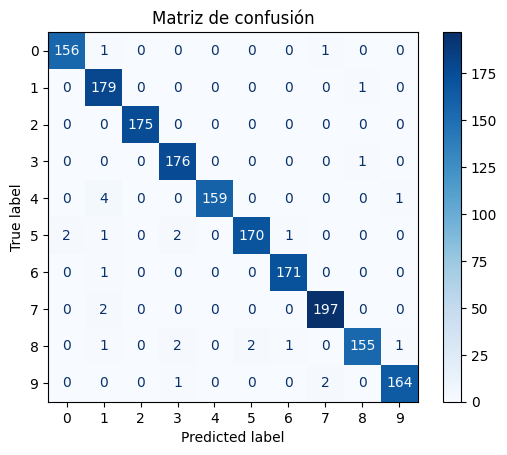

In [8]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(num_classes)
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión")
plt.show()